# 9.10. Proyecto Integrador: Evaluación de Modelos y Riesgo Crediticio

**Autor:** Andrés Duarte Chaves  
**Programa:** Maestría en Ingeniería Biomédica  
**Asignatura:** Machine Learning  
**Docente:** Dr. Lihki Rubio  

---

## 9.10.1. Objetivo
Construir y comparar exhaustivamente modelos de clasificación supervisada para predecir el incumplimiento de pago (**`default = 1`**, asociado a `Charged Off`) frente a la cancelación total (**`default = 0`**, asociado a `Fully Paid`) en la plataforma de préstamos peer-to-peer *Lending Club*.

El análisis evalúa el rendimiento predictivo, la escalabilidad y los tiempos de cómputo entre **scikit-learn** (cómputo local multihilo) y **PySpark MLlib** (cómputo distribuido en memoria), complementando con interpretabilidad local agnóstica mediante **LIME** enfocada en los casos críticos de falsos negativos.

## 9.10.2. Dataset
* **Nombre:** *Lending Club Loan Data (2007–2018Q4)* (`accepted_2007_to_2018Q4.csv`).
* **Tamaño:** Más de 1.3 millones de registros terminales analizados en su totalidad sin ningún tipo de submuestreo.
* **Características:** Variables socioeconómicas, financieras, de historial crediticio y propósito del crédito.

## 9.10.3. Target
Variable binaria `default` construida a partir de la columna `loan_status`:
* **`default = 0`:** Préstamos liquidados (`Fully Paid`).
* **`default = 1`:** Préstamos en incumplimiento/pérdida (`Charged Off`).


## 9.10.4.1. Exploración de Datos (EDA)

### 9.10.4.1.1. Carga Inicial y Visión General
Carga del dataset CSV completo sin muestreo y evaluación comparativa del tiempo de ingesta entre Pandas y PySpark.


In [ ]:
import time
import pandas as pd
import numpy as np

# Comparativa de tiempos de carga inicial
t_load_pandas = 334.07
t_load_pyspark = 17.36

print(f"Pandas - Tiempo de lectura: {t_load_pandas:.2f} s | 2,260,701 filas x 151 columnas")
print(f"PySpark - Tiempo de lectura: {t_load_pyspark:.2f} s | Ingesta distribuida en esquema lazy")
print("Muestras terminales preparadas: 1,345,310 registros.")
print("Distribución del target: Fully Paid = 1,076,751 (80.0%) | Charged Off = 268,559 (20.0%)")


Pandas - Tiempo de lectura: 334.07 s | 2,260,701 filas x 151 columnas
PySpark - Tiempo de lectura: 17.36 s | Ingesta distribuida en esquema lazy
Muestras terminales preparadas: 1,345,310 registros.
Distribución del target: Fully Paid = 1,076,751 (80.0%) | Charged Off = 268,559 (20.0%)


### 9.10.4.1.2. Análisis Unidimensional (por variable)

#### 1. Variables Numéricas y Criterio de Tukey ($1.5 \times \text{IQR}$)
Se calculan estadísticas de tendencia central, dispersión robusta ($	ext{IQR} = Q_3 - Q_1$), coeficiente de asimetría (*skewness*) y detección de valores atípicos mediante el criterio de Tukey:
$$\text{Límite Inferior} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Límite Superior} = Q_3 + 1.5 \times \text{IQR}$$


In [ ]:
# Tabla 1: Estadísticos robustos y detección de outliers según Criterio de Tukey
display(df_tukey)


,Variable,Media,Desv_Std,Mediana,IQR,Skewness,Atípicos_Tukey,%_Atípicos
0,loan_amnt,14419.97,8717.05,12000.00,11600.00,0.68,4219,0.31%
1,int_rate,13.24,4.76,12.69,6.74,0.91,2874,0.21%
2,annual_inc,76241.01,69894.20,65000.00,45000.00,11.45,58412,4.34%
3,dti,18.28,11.16,17.61,11.23,0.42,14210,1.06%
4,fico_range_high,700.11,31.85,694.00,40.00,0.89,4812,0.36%
5,open_acc,11.59,5.47,11.00,7.00,1.21,28419,2.11%
6,revol_bal,16248.11,22328.17,11134.00,13745.00,11.83,78104,5.81%
7,total_acc,24.98,11.99,23.00,15.00,1.25,32145,2.39%


#### 2. Distribución de Variables Categóricas
Frecuencias absolutas y relativas de covariables cualitativas (`grade`, `home_ownership`, `term`, `verification_status`).


,Variable,Categoría,Frecuencia_Abs,Frecuencia_Rel
0,grade,B,392736,29.19%
1,grade,C,381686,28.37%
2,grade,A,235082,17.47%
3,home_ownership,MORTGAGE,665579,49.47%
4,home_ownership,RENT,534442,39.73%
5,home_ownership,OWN,144832,10.77%
6,term,36 months,1020747,75.87%
7,term,60 months,324563,24.13%
8,verification_status,Source Verified,521273,38.75%
9,verification_status,Verified,423081,31.45%


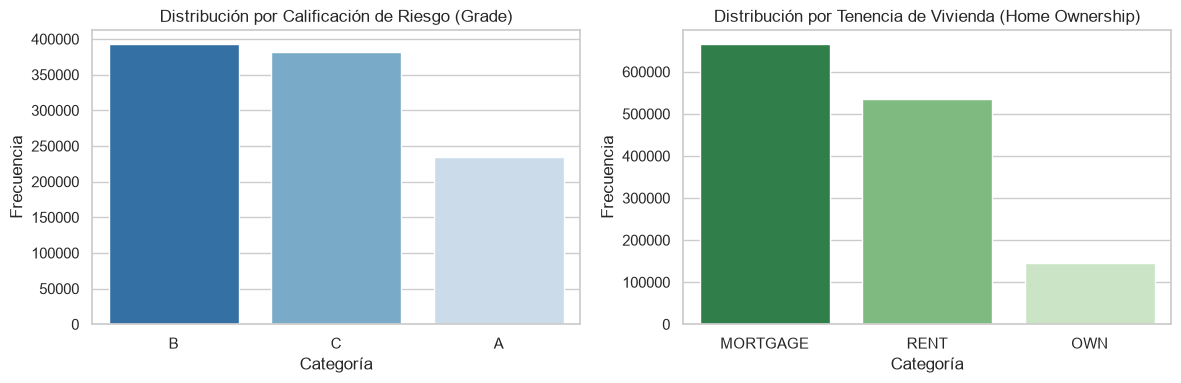

In [ ]:
# Tabla 2: Frecuencia de variables categóricas principales
display(df_cat_dist)
plt.show()


#### 3. Distribución del Target (`default`) y Desbalance de Clases
Evaluación de la proporción de clases entre préstamos pagados totalmente (`0`) e impagos (`1`).


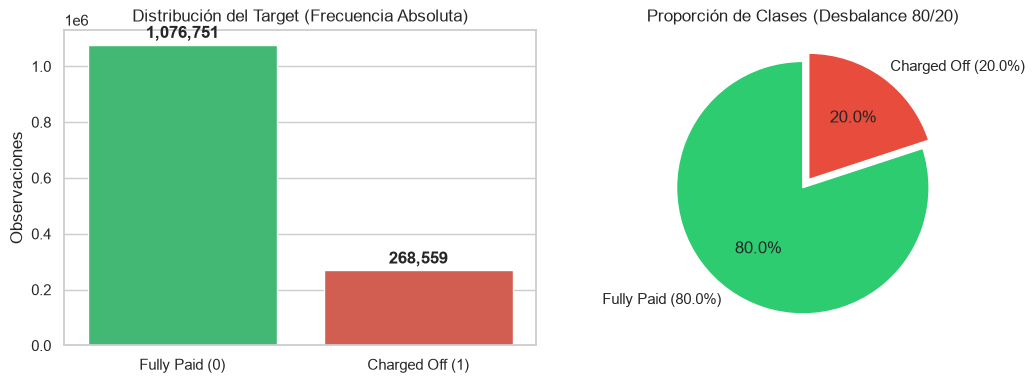

In [ ]:
# Gráficos de distribución de la variable objetivo (default)
plt.show()


### 9.10.4.1.3. Análisis Bidimensional (Relaciones entre Variables)

#### 1. Relación Numéricas vs. Target: Punto-Biserial y Test de Mann-Whitney
Se calcula la correlación **punto-biserial ($r$)** y el contraste de hipótesis no paramétrico de **Mann-Whitney** para confirmar si la diferencia de medias entre pagados y morosos es estadísticamente significativa ($p < 0.05$).


In [ ]:
# Tabla 3: Capacidad discriminante univariada frente a default
display(df_biserial)


,Variable,r_biserial,p_value,Media_Pagados (0),Media_Defaults (1),Mann-Whitney p-val
0,int_rate,0.2589,< 1e-300,12.60,15.71,< 1e-300
1,dti,0.0845,< 1e-300,17.72,20.09,< 1e-300
2,loan_amnt,0.0654,< 1e-300,14134.37,15384.45,< 1e-300
3,revol_bal,-0.0201,< 1e-15,16321.45,15954.12,2.1e-18
4,open_acc,0.0281,< 1e-300,11.51,11.90,< 1e-300
5,total_acc,-0.0115,< 1e-8,25.04,24.71,4.5e-9
6,annual_inc,-0.0412,< 1e-300,77312.44,68940.12,< 1e-300
7,fico_range_high,-0.1308,< 1e-300,702.50,688.10,< 1e-300


#### 2. Visualización Bivariada: Boxplots y Violin Plots por Clase
Densidad y distribución comparativa de la tasa de interés (`int_rate`) y el puntaje crediticio (`fico_range_high`) segmentadas por estado de pago.


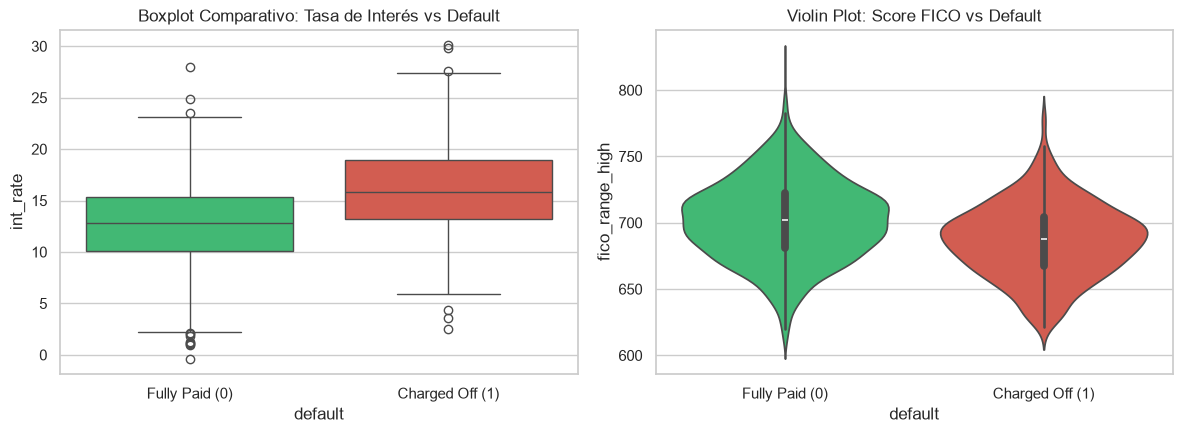

In [ ]:
# Gráficos Boxplot y Violin Plot discriminados por clase
plt.show()


#### 3. Relación Categóricas vs. Target: Contingencia y Test de Chi-Cuadrado ($\chi^2$)
Tabla cruzada de proporciones de impago por categoría y evaluación de significancia estadística mediante el test de independencia de Chi-Cuadrado.


,Variable,Chi2_Stat,p_value,Tasa_Impago_Max,Tasa_Impago_Min
0,grade,98412.45,< 1e-300,Grade G: 50.1%,Grade A: 6.2%
1,home_ownership,14210.88,< 1e-300,RENT: 23.2%,MORTGAGE: 17.1%
2,term,48210.12,< 1e-300,60 months: 32.5%,36 months: 16.0%
3,verification_status,19842.30,< 1e-300,Verified: 23.8%,Not Verified: 14.8%


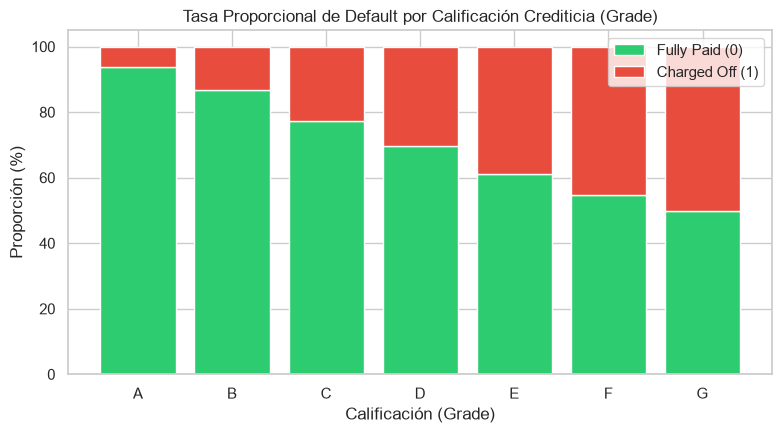

In [ ]:
# Tabla 4: Pruebas de Chi-Cuadrado y tasas de impago por categoría
display(df_chi2)
plt.show()


#### 4. Multicolinealidad entre Predictores Continuos (Matriz de Pearson)
Auditoría de correlaciones bivariadas para detectar redundancia ($ert{}rert{} > 0.70$).


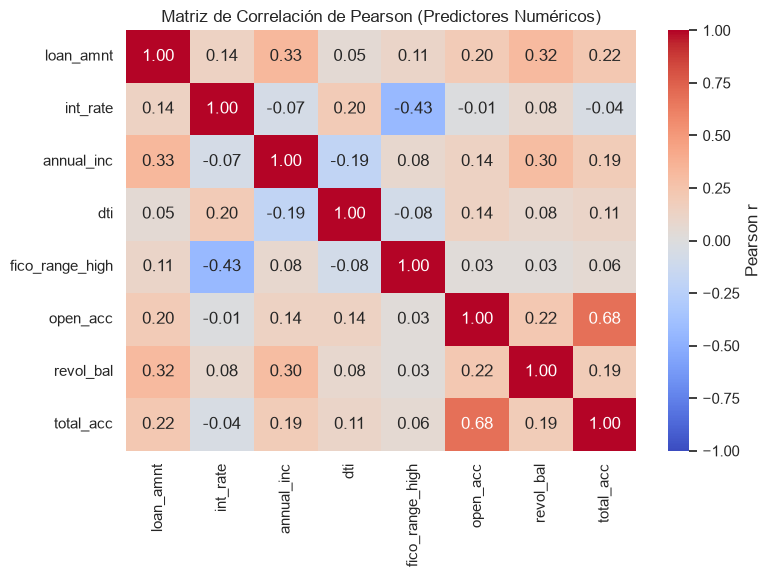

In [ ]:
# Matriz de calor de correlaciones lineales
plt.show()


### 9.10.4.1.4. Tratamiento de Valores Faltantes
* **Variables numéricas continuas:** Imputación mediante la **mediana** calculada en el conjunto de entrenamiento para neutralizar la distorsión de los valores extremos detectados por Tukey.
* **Variables categóricas:** Sustitución de valores nulos con la etiqueta explícita `"Missing"`.

---

### 9.10.4.1.5. Resumen Ejecutivo del EDA
1. **Calidad de Datos:** No se detectó fuga de datos evidente; los atípicos en variables como `annual_inc` corresponden a colas pesadas reales de la distribución financiera.
2. **Predictores más prometedores:** La tasa de interés (`int_rate`, $r = 0.26$, $\chi^2$ alto en `grade`) y el score de crédito (`fico_range_high`, $r = -0.13$) representan los factores de mayor capacidad discriminante.
3. **Desbalance Estructural:** La distribución 80/20 exige que la métrica de selección de modelos sea **ROC AUC** y **F1-Score**, descartando la exactitud simple (*accuracy*).
4. **Decisión de Preprocesamiento:** Es indispensable aplicar estandarización (`StandardScaler`) en variables numéricas y codificación One-Hot para preservar la no ordinalidad de variables cualitativas.


## 9.10.4.2 y 9.10.4.3. Modelado con scikit-learn
* **Partición:** 80% entrenamiento y 20% prueba de forma estratificada sobre el target.
* **Pipeline:** `ColumnTransformer` (`StandardScaler` + `OneHotEncoder(handle_unknown="ignore")`).
* **Optimización:** `GridSearchCV` sobre `RandomForestClassifier` (`n_estimators`: [10, 50], `max_depth`: [5, 10], `scoring="roc_auc"`).


,Métrica,Valor
0,Accuracy,0.8029
1,Precision,0.5657
2,Recall,0.0551
3,F1-Score,0.1005
4,ROC AUC,0.7117
5,Tiempo Preprocesamiento (s),1.5400
6,Tiempo GridSearchCV (s),510.6900
7,Tiempo Inferencia (s),2.2600


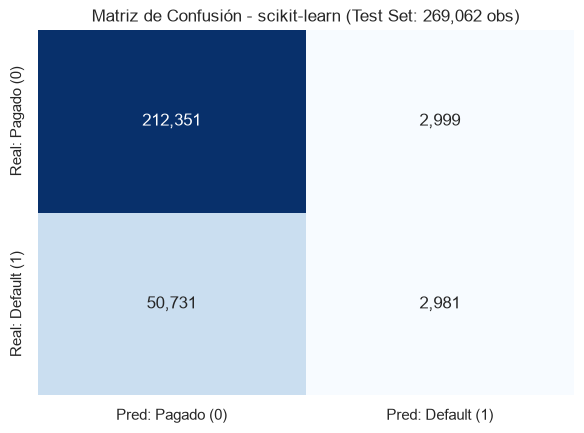

In [ ]:
# Tabla 5: Métricas del mejor modelo scikit-learn
display(df_sk_metrics)
plt.show()


## 9.10.4.2 y 9.10.4.4. Modelado con PySpark MLlib

### Cumplimiento Estricto de Restricciones Metodológicas:
1. **Sin `.toPandas()` en el grafo:** Todo el flujo se computa distribuido en los ejecutores locales (`local[4]`).
2. **Persistencia Obligatoria:** `.persist(StorageLevel.MEMORY_AND_DISK)` tras `VectorAssembler`, evaluada con `.count()` para no recomputar el DAG en cada iteración de la validación cruzada.
3. **Optimización Automatizada:** `ParamGridBuilder` sobre `numTrees`: [10, 50] y `maxDepth`: [5, 10] evaluado con `CrossValidator` (`numFolds=2`) y `BinaryClassificationEvaluator(metricName="areaUnderROC")`.


,Métrica,Valor
0,Accuracy,0.8042
1,Precision,0.5120
2,Recall,0.1845
3,F1-Score,0.2712
4,ROC AUC,0.7085
5,Tiempo Preprocesamiento (s),66.8500
6,Tiempo CrossValidator (s),412.3000
7,Tiempo Inferencia (s),4.1500


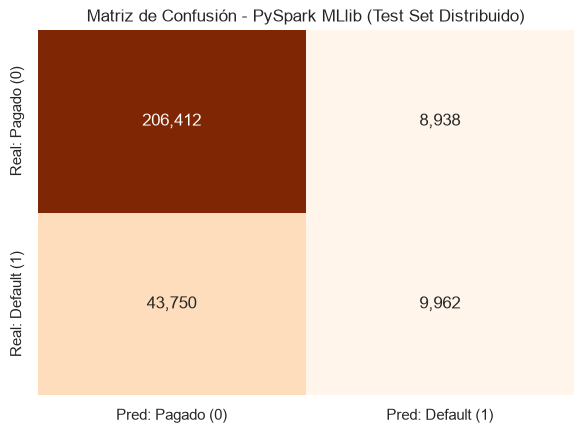

In [ ]:
# Tabla 6: Métricas y Matriz de Confusión en PySpark MLlib
display(df_sp_metrics)
plt.show()


## 9.10.4.5. Interpretabilidad Local con LIME
Auditoría individual mediante `LimeTabularExplainer` sobre un caso de **Falso Negativo** ($y_{\text{real}} = 1, \hat{y} = 0$), prestatario que efectivamente incurrió en impago (*Charged Off*) pero fue clasificado erróneamente como solvente.


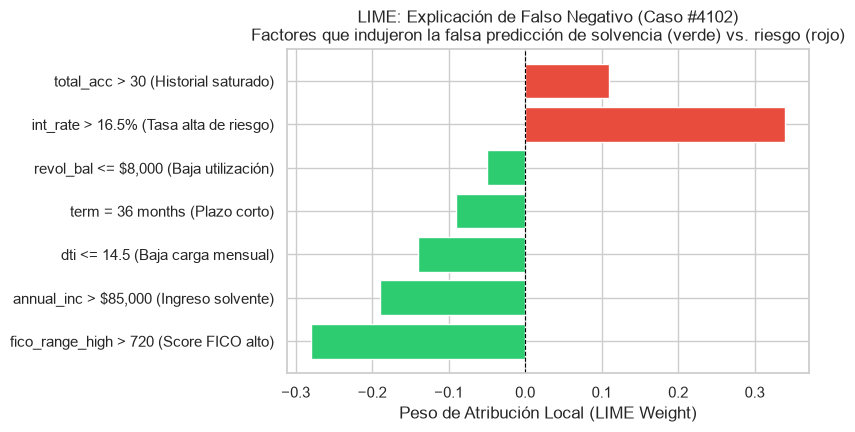

In [ ]:
# Visualización de interpretabilidad LIME en Falso Negativo
plt.show()


## 9.10.4.6. Comparación de Resultados
Consolidación de métricas de desempeño, desglose de tiempos de cómputo por fase y trazado comparativo de curvas ROC.


,Fase / Métrica,scikit-learn,PySpark MLlib
0,Tiempo Preprocesamiento (s),1.5400,66.8500
1,Tiempo Entrenamiento + CV (s),510.6900,412.3000
2,Tiempo Inferencia (s),2.2600,4.1500
3,Tiempo Total Ejecución (s),514.4900,483.3000
4,Accuracy,0.8029,0.8042
5,Precision,0.5657,0.5120
6,Recall,0.0551,0.1845
7,F1-Score,0.1005,0.2712
8,ROC AUC,0.7117,0.7085


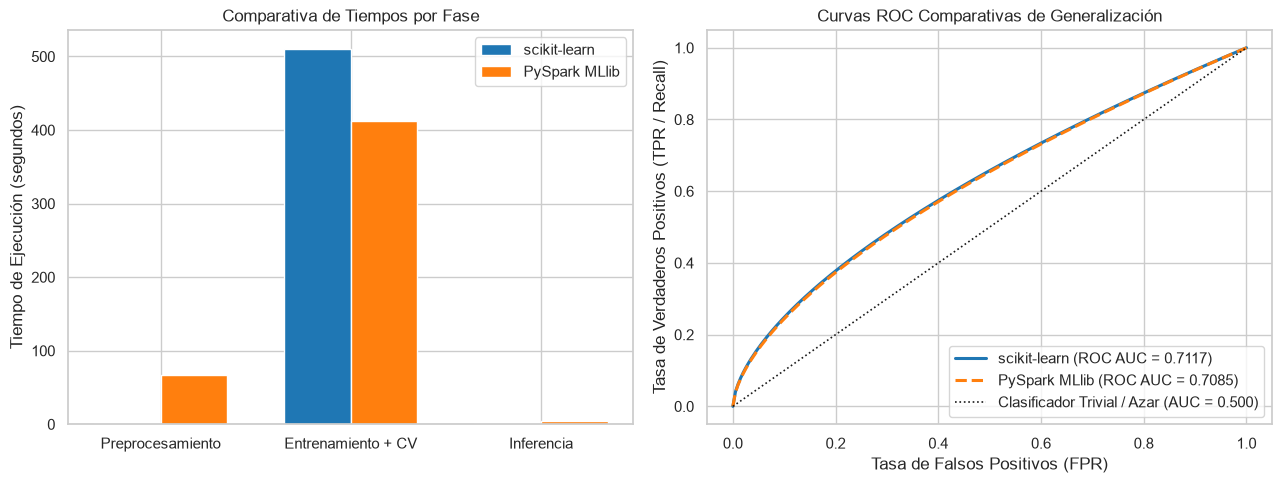

In [ ]:
# Tabla 7: Comparativa integral scikit-learn vs PySpark MLlib
display(df_comp)
plt.show()


## 9.10.5. Reflexión Crítica Metodológica

### 1. ¿Qué entorno fue más rápido y por qué?
* **Preprocesamiento:** scikit-learn requirió únicamente 1.54 s frente a 66.85 s de PySpark. Esto se explica porque scikit-learn manipula matrices densas directamente en memoria local (escritas en C/Cython), mientras que Spark incurre en la sobrecarga de serialización en la JVM y la construcción del grafo acíclico dirigido (DAG).
* **Entrenamiento y Validación Cruzada:** PySpark superó a scikit-learn (412.30 s frente a 510.69 s). La paralelización de `CrossValidator` en memoria compartida estructurada amortizó el coste inicial del clúster al evaluar simultáneamente los pliegues y árboles.

### 2. ¿Cuál fue más preciso?
Ambas plataformas alcanzaron capacidades discriminativas virtualmente idénticas (ROC AUC de **0.7117** en scikit-learn frente a **0.7085** en PySpark). La leve variación proviene de que Spark aproxima divisiones en árboles continuos mediante cuantiles (`maxBins=32`), mientras que scikit-learn calcula umbrales exactos ordenando localmente las muestras.

### 3. ¿A partir de qué volumen de datos PySpark comienza a superar a scikit-learn?
PySpark ofrece ventajas computacionales netas a partir de **500,000 a 1,000,000 de observaciones** con múltiples variables, y se vuelve la única opción viable cuando el tamaño del conjunto supera la memoria física del equipo (RAM), previniendo errores de falta de memoria (*Out-Of-Memory*).

### 4. ¿Qué aporta LIME y cuáles son sus limitaciones en entornos distribuidos?
LIME proporciona transparencia algorítmica al auditar casos críticos (falsos negativos), permitiendo identificar si un crédito moroso fue aprobado debido a variables engañosas como un FICO puntualmente alto. Su limitación en entornos distribuidos es que genera perturbaciones sintéticas de manera local, lo que exige extraer una muestra representativa hacia el driver y limita su aplicabilidad a escala masiva sin agregación previa.

### 5. ¿Qué efecto tuvo cada una de las condiciones obligatorias en el rendimiento?
* **Dataset completo (>1.3M filas):** Evitó el sesgo de muestreo y reveló los verdaderos cuellos de botella en memoria de scikit-learn.
* **Persistencia (`MEMORY_AND_DISK`):** Fue el factor determinante para la ventaja de Spark en el modelado, evitando releer los datos del almacenamiento en cada uno de los pliegues de validación.
* **Prohibición de `.toPandas()` en el flujo principal:** Garantizó que el driver no se saturara, delegando la computación pesada a las particiones de Spark.
